# E23 · Correlation from a tree: phylogenetic regression

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Brain volume, body mass and social group size of primate species (Street et al. 2017, `Primates301`) and the 10kTrees consensus phylogeny of the same 301 species (Arnold, Matthews & Nunn 2010), both as distributed with McElreath's `rethinking` |
| **You will learn** | Reading a tree stored as an R object without R · writing and parsing **Newick** · the phylogenetic covariance as *shared branch length* and the patristic distance · drawing a tree next to the traits · i.i.d. vs **Brownian-motion** regression with `pm.MvNormal` · **Pagel's $\lambda$** · the **Ornstein-Uhlenbeck** model as a GP on patristic distance, its non-identified ridge and a reparameterisation that fixes the sampler · a posterior predictive check that sees phylogenetic signal · **leave-one-out for a correlated likelihood**: the conditional predictive from the precision matrix, and two tempting wrong answers · whitening, and the sparse **tree precision** (a GMRF, like E18's ICAR) · imputing missing group sizes *on the tree* inside the model |

Do primates that live in larger groups have larger brains, for their body size? This is
the "social brain" hypothesis, and the obvious test is a regression across species of log
brain volume on log body mass and log group size. The obvious test is also wrong, because
species are not independent data points. The 24 macaque species in the data share most of
their evolutionary history; if a large brain and a large group happened to arise once in
their common ancestor, a regression counts that single event 24 times.

The fix is old (Felsenstein 1985) and beautifully Bayesian: model the residuals as
correlated, with a covariance that is read off the **phylogeny**. Two species that shared
an ancestor until 2 million years ago have nearly the same residual; a lemur and a baboon,
whose lineages split some 73 million years ago, have independent ones. This notebook builds
that covariance from a real tree, fits the three standard models of trait evolution
(Brownian motion, Pagel's $\lambda$, Ornstein-Uhlenbeck), and watches the social-brain
slope change. On the way it runs into the two technical traps of the topic: a covariance
parameter pair that the data cannot separate, and a model comparison that gives the
opposite answer when the leave-one-out predictive is computed naively.

In [1]:
import gzip
import logging
import struct
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import xarray as xr
from matplotlib.collections import LineCollection
from scipy.linalg import solve_triangular

from pymc_challenges import data

RANDOM_SEED = 2017
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)  # no sampler banner for each of the ~8 fits
warnings.filterwarnings("ignore", message="Data in .* contains missing values")  # automatic imputation notice
BLUE, ORANGE, AQUA, GREY, PURPLE = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8e5bd0"
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")


def fit(model, **kw):
    """One place for the sampler settings (nutpie, 4 chains x 1000 draws); report divergences and time."""
    t0 = time.time()
    with model:
        idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False, **kw)
    n_div = int(idata.sample_stats["diverging"].sum())
    print(f"  {model.name}: {time.time() - t0:.1f} s (incl. compile), divergences = {n_div}")
    return idata


def summ(idata, names):
    """az.summary for a named model: variables are stored as '<model>::<name>'."""
    prefix = next(iter(idata.posterior.data_vars)).split("::")[0]
    out = az.summary(idata, var_names=[f"{prefix}::{n}" for n in names], round_to=3)
    out.index = [i.split("::")[1] for i in out.index]
    return out


def draws(idata, var):
    return idata.posterior[var].stack(sample=("chain", "draw")).transpose("sample", ...).to_numpy()

PyMC 6.3.2, ArviZ 1.3.0


## 1 · The data, and a tree stored as an R object

The trait table is an ordinary CSV. Note the gaps: of 301 species, 184 have a brain volume,
and of the 182 with both brain and body mass, only 151 also have a group size.

In [2]:
data.describe("primates301")
prim = data.load("primates301")
print(prim[["brain", "body", "group_size"]].notna().sum().to_string())
has_bb = prim.brain.notna() & prim.body.notna()
print(f"brain & body: {has_bb.sum()},  brain & body & group size: {(has_bb & prim.group_size.notna()).sum()}")
prim[["name", "genus", "brain", "body", "group_size"]].sample(5, random_state=1)

primates301: 301 primate species: brain volume (cc), body mass (g), mean group size, gestation, longevity, social learning counts and research effort; many NAs (e.g. 114 species lack group size).
  source: Street, Navarrete, Reader & Laland (2017, PNAS 114:7908), primate life history and brain size, via McElreath's `rethinking`.
  url:    https://raw.githubusercontent.com/rmcelreath/rethinking/master/data/Primates301.csv
brain         184
body          238
group_size    187
brain & body: 182,  brain & body & group size: 151


,name,genus,brain,body,group_size
285,Theropithecus_gelada,Theropithecus,133.33,15350.0,10.00
248,Presbytis_comata,Presbytis,80.30,6695.0,7.05
150,Lepilemur_microdon,Lepilemur,9.75,970.0,1.00
217,Nycticebus_javanicus,Nycticebus,NaN,NaN,NaN
107,Eulemur_macaco_macaco,Eulemur,24.51,2390.0,9.20


The tree is the awkward part. Phylogenies are usually exchanged as **Newick** or **Nexus**
text, but `rethinking` ships this one only as an R object (class `ape::phylo`) in a
compressed `.rda` file. Rather than install R, we read R's serialisation format directly:
it is a gzip stream of big-endian ("XDR") records, each a 32-bit header whose low byte says
the type (integer vector, double vector, string, list, pairlist...) and whose flag bits say
whether attributes and a tag follow. Forty lines handle every type an `ape` tree uses.

In [3]:
def read_r_object(path):
    """Minimal reader for R's XDR serialisation (.rda/.rds), enough for ape `phylo` trees."""
    buf = gzip.open(path).read()
    assert buf[:7] in (b"RDX2\nX\n", b"RDX3\nX\n"), "not an XDR .rda file"
    pos, refs = 7, []

    def i32():
        nonlocal pos
        pos += 4
        return struct.unpack(">i", buf[pos - 4:pos])[0]

    def item():
        nonlocal pos
        flags = i32()
        kind, has_attr, has_tag = flags & 0xFF, flags & (1 << 9), flags & (1 << 10)
        if kind == 254:                                   # NULL
            return None
        if kind == 255:                                   # reference to an earlier symbol
            return refs[(flags >> 8) - 1]
        if kind == 1:                                     # symbol: its name follows
            refs.append(item())
            return refs[-1]
        if kind == 9:                                     # string
            n = i32()
            pos += max(n, 0)
            return None if n == -1 else buf[pos - n:pos].decode()
        if kind == 2:                                     # pairlist -> dict (tag: value)
            out = {}
            while kind == 2:
                attrs = item() if has_attr else None  # noqa: F841 (pairlist attributes unused)
                tag = item() if has_tag else None
                out[tag] = item()
                flags = i32()
                kind, has_attr, has_tag = flags & 0xFF, flags & (1 << 9), flags & (1 << 10)
            return out
        n = i32()
        if kind in (10, 13):                              # logical / integer vector
            value, pos = np.frombuffer(buf, ">i4", n, pos).astype(int), pos + 4 * n
        elif kind == 14:                                  # double vector
            value, pos = np.frombuffer(buf, ">f8", n, pos).astype(float), pos + 8 * n
        elif kind in (16, 19):                            # character vector / list
            value = [item() for _ in range(n)]
        else:
            raise NotImplementedError(f"R type {kind}")
        attrs = item() if has_attr else None
        if kind == 19 and attrs and "names" in attrs:     # named list -> dict
            value = dict(zip(attrs["names"], value))
        return value

    version = i32()
    pos += 8                                              # writer and minimal reader versions
    if version == 3:                                      # native encoding name
        pos += 4 + struct.unpack(">i", buf[pos:pos + 4])[0]
    return item()


data.describe("primates301_tree")
phylo = read_r_object(data.path("primates301_tree"))["Primates301_nex"]
print({k: (type(v).__name__, len(v)) for k, v in phylo.items()})

primates301_tree: Rooted ultrametric tree (branch lengths in Myr, depth 73): edge matrix, edge.length, Nnode, tip.label. Not a table: an R serialisation (gzip XDR) - parse data.path() (see E23).
  source: 10kTrees consensus phylogeny (Arnold, Matthews & Nunn 2010, Evol. Anthropol. 19:114) of the 301 `primates301` species, as an R `ape::phylo` object in McElreath's `rethinking`.
  url:    https://raw.githubusercontent.com/rmcelreath/rethinking/master/data/Primates301_nex.rda
{'edge': ('ndarray', 1188), 'edge.length': ('ndarray', 594), 'Nnode': ('ndarray', 1), 'tip.label': ('list', 301)}


An `ape` tree is an **edge table**: row $e$ says "node `edge[e,0]` is the parent of node
`edge[e,1]`, along a branch of length `edge.length[e]`". Tips are nodes $1..301$ (R counts
from 1), internal nodes $302..$, and 302 is the root. The matrix is stored column by
column, as R does. 294 internal nodes for 301 tips (a fully bifurcating tree has 300)
means a few **polytomies**: nodes where the phylogeny does not resolve the branching order.

From the edge table everything follows from one object, the **ancestry matrix**
$A_{nm} = 1$ if the branch above node $m$ lies on the path from the root to node $n$. The
depth of a node is $A\,\ell$ (with $\ell$ the branch lengths), and the covariance of
Brownian motion on the tree is

$$C = A \,\mathrm{diag}(\ell)\, A^\top, \qquad C_{ij} = \text{length of the path the root-to-}i
\text{ and root-to-}j\text{ paths share} = \text{depth of their most recent common ancestor.}$$

That is literally a linear model: each branch contributes one independent normal increment
with variance $\sigma^2 \ell_e$, and a species' trait is the sum of the increments on its
path. Two species share exactly the increments on their shared path. The **patristic
distance** (length of the path between them through the tree) is
$D_{ij} = C_{ii} + C_{jj} - 2C_{ij}$.

In [4]:
edge = np.asarray(phylo["edge"]).reshape(2, -1).T - 1       # column-major, 1-based in R
edge_len = np.asarray(phylo["edge.length"], dtype=float)
tip_label = list(phylo["tip.label"])
n_tip = len(tip_label)
n_node = n_tip + int(phylo["Nnode"][0])
parent = np.full(n_node, -1)
blen = np.zeros(n_node)                 # length of the branch ABOVE each node (0 for the root)
parent[edge[:, 1]] = edge[:, 0]
blen[edge[:, 1]] = edge_len
children = [[] for _ in range(n_node)]
for p, c in edge:
    children[p].append(c)
root = int(edge[0, 0])


def ancestry(parent):
    """A[n, m] = 1 if the branch above m is on the root-to-n path (root has no branch)."""
    A = np.zeros((len(parent), len(parent)))
    for n in range(len(parent)):
        m = n
        while parent[m] >= 0:
            A[n, m] = 1.0
            m = parent[m]
    return A


Anc = ancestry(parent)
depth = Anc @ blen
C_full = (Anc[:n_tip] * blen) @ Anc[:n_tip].T
D_full = np.diag(C_full)[:, None] + np.diag(C_full)[None, :] - 2 * C_full
T = depth[:n_tip].max()
print(f"{n_tip} tips, {n_node - n_tip} internal nodes, root = node {root + 1}")
print(f"tip depths: {depth[:n_tip].min():.3f} to {depth[:n_tip].max():.3f}  -> ultrametric, T = {T:.1f} Myr")
print(f"shortest terminal branch {blen[:n_tip].min():.3f} Myr, longest patristic distance {D_full.max():.1f} Myr")

301 tips, 294 internal nodes, root = node 302
tip depths: 72.973 to 73.003  -> ultrametric, T = 73.0 Myr
shortest terminal branch 0.020 Myr, longest patristic distance 146.0 Myr


Every tip sits at depth 73.0 (to within 0.03): the tree is **ultrametric**, a chronogram
whose branch lengths are times in millions of years, with all species observed today. So
the diagonal of $C$ is constant and $D_{ij} = 2(T - C_{ij})$: covariance and distance carry
the same information. (For a tree with fossils, or branch lengths in substitutions, the
diagonal varies, and "correlation" and "covariance" versions of the models below differ.)

### Newick, both ways

Newick is how you will usually meet a tree: nested parentheses, `name:length`. To make the
covariance concrete, cut six species out of the real tree, write them as Newick (a unary
node left by the pruning is merged into its child by adding the branch lengths), parse the
string back with a 20-line recursive-descent parser, and build $C$ from the parsed tree.

In [5]:
def to_newick(node, keep):
    """(newick string, length of the branch above) for the subtree of `keep` tips below node."""
    if node < n_tip:
        return (tip_label[node], blen[node]) if node in keep else None
    parts = [r for c in children[node] if (r := to_newick(c, keep)) is not None]
    if not parts:
        return None
    if len(parts) == 1:                                   # unary after pruning: merge branches
        return parts[0][0], parts[0][1] + blen[node]
    return "(" + ",".join(f"{s}:{ell:.4f}" for s, ell in parts) + ")", blen[node]


def parse_newick(s):
    """Recursive-descent Newick parser -> (names, parent, branch length); node 0 is the root."""
    names, par, length, pos = [], [], [], 0

    def node(p):
        nonlocal pos
        k = len(par)
        names.append(None), par.append(p), length.append(0.0)
        if s[pos] == "(":
            pos += 1
            node(k)
            while s[pos] == ",":
                pos += 1
                node(k)
            assert s[pos] == ")", f"expected ')' at {pos}"
            pos += 1
        start = pos
        while s[pos] not in ",():;":
            pos += 1
        names[k] = s[start:pos] or None
        if s[pos] == ":":
            pos += 1
            start = pos
            while s[pos] not in ",();":
                pos += 1
            length[k] = float(s[start:pos])

    node(-1)
    return names, np.array(par), np.array(length)


six = ["Homo_sapiens", "Pan_troglodytes_verus", "Gorilla_gorilla_gorilla", "Pongo_abelii",
       "Macaca_mulatta", "Lemur_catta"]
nwk = to_newick(root, {tip_label.index(s) for s in six})[0] + ";"
print(nwk, "\n")
names_s, parent_s, len_s = parse_newick(nwk)
is_tip = np.array([not np.any(parent_s == k) for k in range(len(parent_s))])
A_s = ancestry(parent_s)[is_tip]
C_six = (A_s * len_s) @ A_s.T
labels_s = [names_s[k] for k in np.flatnonzero(is_tip)]
print(pd.DataFrame(C_six, index=labels_s, columns=[s.split("_")[0] for s in labels_s]).round(1))
ix = [tip_label.index(s) for s in labels_s]
print(f"\nmax |C(parsed Newick) - C(full tree)| = {np.abs(C_six - C_full[np.ix_(ix, ix)]).max():.1e}")

((Macaca_mulatta:30.0000,((Gorilla_gorilla_gorilla:8.6522,(Homo_sapiens:6.1759,Pan_troglodytes_verus:6.1759):2.4764):6.4802,Pongo_abelii:15.1325):14.8675):43.0030,Lemur_catta:73.0030); 

                         Macaca  Gorilla  Homo   Pan  Pongo  Lemur
Macaca_mulatta             73.0     43.0  43.0  43.0   43.0    0.0
Gorilla_gorilla_gorilla    43.0     73.0  64.4  64.4   57.9    0.0
Homo_sapiens               43.0     64.4  73.0  66.8   57.9    0.0
Pan_troglodytes_verus      43.0     64.4  66.8  73.0   57.9    0.0
Pongo_abelii               43.0     57.9  57.9  57.9   73.0    0.0
Lemur_catta                 0.0      0.0   0.0   0.0    0.0   73.0

max |C(parsed Newick) - C(full tree)| = 1.2e-04


Read the matrix as time: humans and chimpanzees share 67 of their 73 million years of
history (they split about 6 Myr ago), humans and gorillas 64, humans and orangutans 58,
humans and macaques 45 (the ape / Old-World-monkey split), and every other species shares
nothing with the ring-tailed lemur: the first split in the tree separates the
strepsirrhines (lemurs, lorises, galagos) from everything else. The parsed Newick
reproduces the full-tree matrix to the four decimals we wrote.

## 2 · The tree next to the traits

A tree plot is just a set of line segments: each node at $x$ = its depth and $y$ = the
average height of its children, a horizontal segment for its branch and a vertical one
joining its children. Tips are placed in "cladewise" (depth-first) order, which is also the
order we will use for the species in every matrix below, so that clades appear as blocks.

Old World monkeys           108
lemurs, lorises, galagos     97
New World monkeys            67
apes                         25
tarsiers                      4


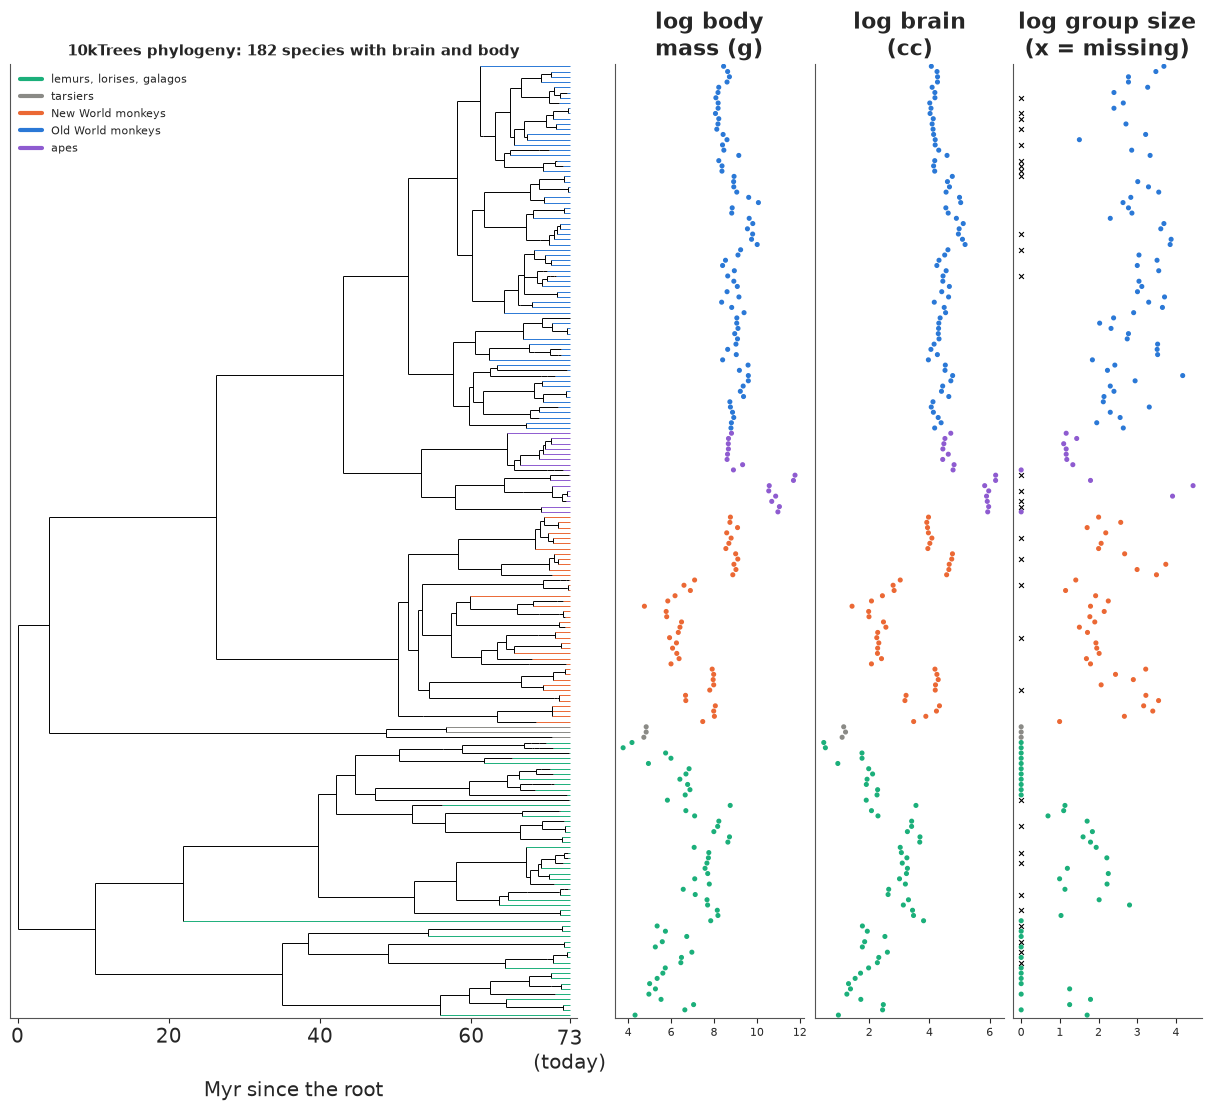

In [6]:
def cladewise(node=root):
    if node < n_tip:
        return [node]
    return [t for c in children[node] for t in cladewise(c)]


tip_order = cladewise()
genus_of = prim.set_index("name").genus


def mrca(names):
    rows = Anc[[tip_label.index(s) for s in names]]
    shared = np.flatnonzero(rows.all(axis=0))
    return shared[np.argmax(depth[shared])] if len(shared) else root


def first(genus):
    return [s for s in tip_label if genus_of[s] == genus]


clades = {   # clade -> (MRCA node, colour)
    "lemurs, lorises, galagos": (mrca(["Lemur_catta", "Galago_senegalensis"]), AQUA),
    "tarsiers": (mrca(first("Tarsius")), GREY),
    "New World monkeys": (mrca(["Callithrix_jacchus", first("Alouatta")[0], first("Pithecia")[0]]), ORANGE),
    "Old World monkeys": (mrca(["Macaca_mulatta", first("Colobus")[0]]), BLUE),
    "apes": (mrca(["Homo_sapiens", first("Hylobates")[0]]), PURPLE),
}
tip_clade = np.array([next((k for k, (m, _) in clades.items() if Anc[i, m] or i == m), "other")
                      for i in range(n_tip)])
print(pd.Series(tip_clade).value_counts().to_string())


def draw_tree(ax, tips, lw=0.7):
    """Rectangular phylogram of the subtree spanned by `tips` (indices, in plotting order)."""
    y = {t: k for k, t in enumerate(tips)}
    segs, cols = [], []

    def walk(node):
        if node < n_tip:
            return y.get(node)
        ys = [(c, yc) for c in children[node] if (yc := walk(c)) is not None]
        if not ys:
            return None
        for c, yc in ys:
            segs.append([(depth[node], yc), (depth[c], yc)])
            cols.append(clades[tip_clade[c]][1] if c < n_tip and tip_clade[c] in clades else "k")
        segs.append([(depth[node], min(v for _, v in ys)), (depth[node], max(v for _, v in ys))])
        cols.append("k")
        y[node] = np.mean([v for _, v in ys])
        return y[node]

    walk(root)
    ax.add_collection(LineCollection(segs, colors=cols, linewidths=lw))
    ax.set(xlim=(-1, T + 1), ylim=(len(tips) - 0.5, -0.5), yticks=[], xlabel="Myr since the root")
    ax.set_xticks([0, 20, 40, 60, T], ["0", "20", "40", "60", f"{T:.0f}\n(today)"])


# species with brain and body mass, in tree order
bb_names = set(prim.name[has_bb])
tips_bb = [t for t in tip_order if tip_label[t] in bb_names]
df = prim.set_index("name").loc[[tip_label[t] for t in tips_bb]].copy()
df["tip"], df["clade"] = tips_bb, tip_clade[tips_bb]
for c in ["brain", "body", "group_size"]:
    df["log_" + c] = np.log(df[c])


def trait_strips(axes, df, cols, titles):
    yy = np.arange(len(df))
    colors = [clades[c][1] for c in df.clade]
    for ax, col, title in zip(axes, cols, titles):
        v = df[col].to_numpy()
        ok = np.isfinite(v)
        ax.scatter(v[ok], yy[ok], c=np.array(colors)[ok], s=7)
        ax.scatter(np.full((~ok).sum(), np.nanmin(v)), yy[~ok], marker="x", color="k", s=12, lw=0.8)
        ax.set(title=title, yticks=[], ylim=(len(df) - 0.5, -0.5))
        ax.tick_params(labelsize=8)


fig, axes = plt.subplots(1, 4, figsize=(12, 11), sharey=True, gridspec_kw={"width_ratios": [3, 1, 1, 1]})
draw_tree(axes[0], tips_bb)
axes[0].set_title(f"10kTrees phylogeny: {len(tips_bb)} species with brain and body", fontsize=11)
trait_strips(axes[1:], df, ["log_body", "log_brain", "log_group_size"],
             ["log body\nmass (g)", "log brain\n(cc)", "log group size\n(x = missing)"])
for name, (_, col) in clades.items():
    axes[0].plot([], [], color=col, lw=3, label=name)
axes[0].legend(loc="upper left", fontsize=8);

The phylogenetic structure of the traits is visible without any model: body and brain
size come in clade-sized blocks (small-bodied lemurs, mouse lemurs and marmosets; large
apes and baboons), and so, less sharply, does group size (large troops in the Old World
monkeys; solitary animals - log group size 0 - in many lemurs, lorises and galagos). Any cross-species
correlation between brain and group size can therefore come from a few deep splits. The
crosses mark the 31 species with brain and body mass but no group size (section 9).

The 151 complete species are the regression data for sections 3-8. Every variable is
logged and standardised on that sample; the covariance is scaled by the tree depth $T$,
so that $R = C/T$ has ones on the diagonal (a correlation matrix, because the tree is
ultrametric), and distances by the maximum $2T$.

N = 151 species; corr(M, G) = 0.63; mean off-diagonal correlation in R = 0.30


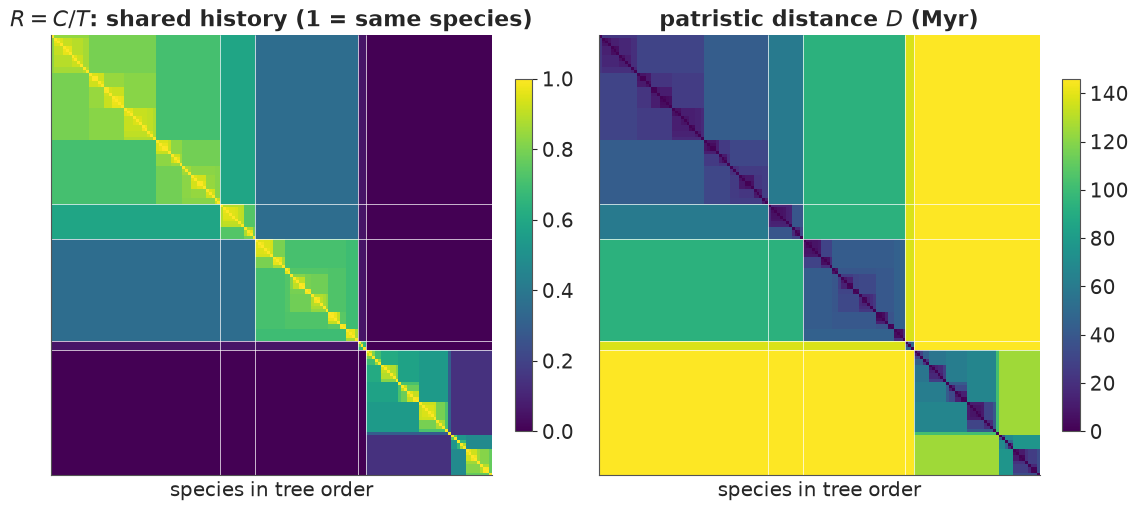

In [7]:
cc = df.dropna(subset=["group_size"]).copy()
N = len(cc)


def standardise(x):
    return (x - x.mean()) / x.std()


B, M, G = (standardise(cc[c].to_numpy()) for c in ["log_brain", "log_body", "log_group_size"])
tips_cc = cc.tip.to_numpy()
R = C_full[np.ix_(tips_cc, tips_cc)] / T
Dn = D_full[np.ix_(tips_cc, tips_cc)] / (2 * T)
species = cc.index.to_numpy(dtype=object)
print(f"N = {N} species; corr(M, G) = {np.corrcoef(M, G)[0, 1]:.2f}; "
      f"mean off-diagonal correlation in R = {(R.sum() - N) / (N * (N - 1)):.2f}")

bounds = np.flatnonzero(cc.clade.to_numpy()[1:] != cc.clade.to_numpy()[:-1]) + 0.5
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, mat, title in [(axes[0], R, "$R = C/T$: shared history (1 = same species)"),
                       (axes[1], Dn * 2 * T, "patristic distance $D$ (Myr)")]:
    im = ax.imshow(mat, cmap="viridis", interpolation="nearest")
    for b in bounds:
        ax.axhline(b, color="w", lw=0.5)
        ax.axvline(b, color="w", lw=0.5)
    ax.set(title=title, xticks=[], yticks=[], xlabel="species in tree order")
    fig.colorbar(im, ax=ax, shrink=0.8)

In tree order the covariance is a nest of blocks: the big block of the Old World monkeys,
the apes, the New World monkeys, the strepsirrhines (which share nothing with the rest:
the zero rows), and within them genera. This is the matrix we will put into `pm.MvNormal`.

## 3 · The i.i.d. regression, and a check that sees what it misses

$$B_i \sim \text{Normal}(a + \beta_M M_i + \beta_G G_i,\ \sigma)$$

Priors for standardised data: $a \sim \text{N}(0, 1)$, $\beta_M, \beta_G \sim \text{N}(0, 0.5)$
(a one-sd change in a predictor moving brain size by more than one sd is implausible, not
impossible), $\sigma \sim \text{Exponential}(1)$. All models below share these; the only
thing that changes is the covariance of the residuals.

In [8]:
def regression(kind, name=None):
    """Brain ~ body + group size with residual covariance of the given kind."""
    with pm.Model(coords={"species": species}, name=name or kind) as m:
        a = pm.Normal("a", 0, 1)
        bM = pm.Normal("bM", 0, 0.5)
        bG = pm.Normal("bG", 0, 0.5)
        mu = pm.Deterministic("mu", a + bM * M + bG * G, dims="species")
        if kind == "iid":
            sigma = pm.Exponential("sigma", 1)
            pm.Normal("B", mu, sigma, observed=B, dims="species")
            return m
        if kind == "bm":
            sigma = pm.Exponential("sigma", 1)
            K = sigma**2 * R
        elif kind == "lambda":
            sigma = pm.Exponential("sigma", 1)
            lam = pm.Beta("lam", 1, 1)
            K = sigma**2 * (lam * R + (1 - lam) * np.eye(N))
        elif kind == "ou":                      # GP with exponential kernel on patristic distance
            eta2 = pm.HalfNormal("eta2", 5)
            rho = pm.HalfNormal("rho", 5)
            K = eta2 * pm.math.exp(-rho * Dn) + 1e-6 * np.eye(N)
        elif kind == "ou_rate":                 # same model, sampled in (rate, rho)
            rate = pm.HalfNormal("rate", 1)
            rho = pm.HalfNormal("rho", 5)
            eta2 = pm.Deterministic("eta2", rate / rho)
            K = eta2 * pm.math.exp(-rho * Dn) + 1e-6 * np.eye(N)
        pm.MvNormal("B", mu, cov=K, observed=B, dims="species")
    return m


m_iid = regression("iid")
with m_iid:
    prior = pm.sample_prior_predictive(500, random_seed=RANDOM_SEED)
pp = prior.prior_predictive["iid::B"].to_numpy().ravel()
print(f"prior predictive of standardised log brain: 5-95% [{np.quantile(pp, 0.05):.1f}, {np.quantile(pp, 0.95):.1f}], "
      f"P(|B| > 5) = {np.mean(np.abs(pp) > 5):.3f}")
fits = {"iid": fit(m_iid)}
print(summ(fits["iid"], ["a", "bM", "bG", "sigma"]))

prior predictive of standardised log brain: 5-95% [-2.8, 2.8], P(|B| > 5) = 0.015


  iid: 1.4 s (incl. compile), divergences = 0
        mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  mcse_mean  \
a      0.000  0.017    -0.027     0.028  4175.959  3177.462  1.001        0.0   
bM     0.893  0.023     0.855     0.929  2263.894  2367.837  1.002        0.0   
bG     0.123  0.023     0.087     0.160  2185.474  2781.644  1.002        0.0   
sigma  0.217  0.013     0.198     0.238  3976.787  3149.547  1.002        0.0   

       mcse_sd  
a          0.0  
bM         0.0  
bG         0.0  
sigma      0.0  


The prior predictive is wide but not absurd (most mass within a few sds of the observed
range). The i.i.d. fit says: at fixed body mass, a one-sd larger (log) group size goes
with a 0.12 sd larger brain, with a tight interval that excludes zero. The social brain,
confirmed?

A posterior predictive check tailored to the question: if the model is right, a species'
residual should say nothing about its **closest relative's** residual. For every species
$i$ let $\text{nn}(i)$ be the species at the smallest patristic distance, and compute
$\text{corr}(r_i, r_{\text{nn}(i)})$ for the observed residuals $r = B - \mu$ and for
residuals of data replicated from the posterior predictive, draw by draw.

In [9]:
D_cc = Dn.copy()
np.fill_diagonal(D_cc, np.inf)
nn = D_cc.argmin(axis=1)
print(f"median distance to the nearest relative: {np.median(D_cc.min(axis=1)) * 2 * T:.1f} Myr")


def sister_ppc(idata, model, n_thin=4):
    """corr(residual, nearest relative's residual): observed vs replicated, per posterior draw."""
    post = idata.posterior.isel(draw=slice(None, None, n_thin))
    with model:
        ppc = pm.sample_posterior_predictive(post, random_seed=RANDOM_SEED, progressbar=False)
    mu = post[f"{model.name}::mu"].stack(sample=("chain", "draw")).transpose("sample", ...).to_numpy()
    rep = ppc.posterior_predictive[f"{model.name}::B"].stack(sample=("chain", "draw")).transpose("sample", ...).to_numpy()

    def stat(r):
        r = r - r.mean(axis=1, keepdims=True)
        return (r * r[:, nn]).sum(1) / np.sqrt((r**2).sum(1) * (r[:, nn] ** 2).sum(1))

    return stat(B - mu), stat(rep - mu)


ppc_stats = {"iid": sister_ppc(fits["iid"], m_iid)}
obs, rep = ppc_stats["iid"]
print(f"observed: {np.median(obs):.2f}   replicated 90%: [{np.quantile(rep, 0.05):.2f}, "
      f"{np.quantile(rep, 0.95):.2f}]   P(rep >= obs) = {np.mean(rep >= obs):.3f}")

median distance to the nearest relative: 7.4 Myr
observed: 0.75   replicated 90%: [-0.17, 0.16]   P(rep >= obs) = 0.000


The residuals of close relatives are strongly correlated in the data and uncorrelated in
every replicate: the i.i.d. model has not seen the tree, and the tree is in the residuals.
Its tight interval for $\beta_G$ rests on 151 independent observations that do not exist.

## 4 · Brownian motion: the residual evolves along the tree

If the residual (brain size not explained by body size and group size) drifts as a
Brownian motion along the branches, with rate $\sigma^2$ per unit of scaled time, then
$$B \sim \text{MvNormal}(a + \beta_M M + \beta_G G,\ \sigma^2 R).$$
This is the Bayesian version of phylogenetic generalised least squares (PGLS; Grafen 1989),
equivalent to Felsenstein's independent contrasts. Note what $a$ now is: the expected
residual-adjusted brain size **at the root**, 73 million years ago.

**Pagel's $\lambda$** (Pagel 1999) interpolates: multiply every off-diagonal element of $R$
by $\lambda \in [0, 1]$. $\lambda = 0$ is the i.i.d. model, $\lambda = 1$ Brownian motion;
equivalently $\sigma^2(\lambda R + (1 - \lambda) I)$, a Brownian part plus a species-level
"nugget" (on an ultrametric tree the two forms are the same, because $\text{diag}(R) = 1$).
The nugget absorbs whatever is species-specific and not inherited: measurement error in a
handful of skulls, recent rapid change, intraspecific variation.

In [10]:
for kind in ["bm", "lambda"]:
    fits[kind] = fit(regression(kind))
print(summ(fits["bm"], ["a", "bM", "bG", "sigma"]))
print(summ(fits["lambda"], ["a", "bM", "bG", "sigma", "lam"]))

  bm: 2.6 s (incl. compile), divergences = 0


  lambda: 3.6 s (incl. compile), divergences = 0
        mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  mcse_mean  \
a     -0.193  0.171    -0.469     0.078  5964.043  3409.835  1.000      0.002   
bM     0.701  0.036     0.644     0.758  5202.148  3340.025  1.000      0.000   
bG    -0.013  0.020    -0.046     0.019  5598.085  3235.417  1.002      0.000   
sigma  0.401  0.024     0.366     0.439  5666.307  3152.754  1.001      0.000   

       mcse_sd  
a        0.002  
bM       0.001  
bG       0.000  
sigma    0.000  
        mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  mcse_mean  \
a     -0.121  0.118    -0.312     0.065  3829.781  2848.231  1.001      0.002   
bM     0.766  0.031     0.716     0.815  3165.246  3184.099  1.000      0.001   
bG     0.026  0.019    -0.005     0.057  3506.857  3012.200  1.000      0.000   
sigma  0.277  0.022     0.242     0.313  1904.451  1906.837  1.001      0.001   
lam    0.954  0.018     0.922     0.977  1938.220  2151

The group-size slope collapses: from 0.12 under i.i.d. to about zero under Brownian motion
and to about 0.03 (interval touching zero) under $\lambda$. $\lambda$ itself is estimated
at 0.95 (89% interval [0.92, 0.98]): residual brain size is almost entirely phylogenetic, with a small but
clearly non-zero species-specific component. The book-keeping of uncertainty changes too,
and not uniformly - see section 6.

## 5 · Ornstein-Uhlenbeck: a Gaussian process on the tree, and its ridge

Brownian motion lets a trait wander without bound. The **Ornstein-Uhlenbeck** process
pulls it back towards an optimum with strength $\alpha$. On an ultrametric tree, with the
root at stationarity, the covariance is
$$K_{ij} = \eta^2 \exp(-\rho\, D_{ij} / 2T),$$
which is exactly the exponential (Matérn-1/2) Gaussian-process kernel of E05 with
**patristic distance** in place of Euclidean distance; $\rho = 2T\alpha$ and the
phylogenetic half-life is $\ln 2 / \alpha = 2T \ln 2 / \rho$. (It is the model `rethinking`
fits with `cov_GPL1`.) First attempt: weakly informative half-normal priors on $\eta^2$ and
$\rho$ separately. Both OU fits use `target_accept=0.95`: at the default 0.8 they produce a
few divergences, a first sign of awkward geometry.

In [11]:
m_ou = regression("ou")
fits["ou"] = fit(m_ou, target_accept=0.95)
print(summ(fits["ou"], ["bM", "bG", "eta2", "rho"]))
e2, rh = draws(fits["ou"], "ou::eta2"), draws(fits["ou"], "ou::rho")
print(f"corr(log eta2, log rho) = {np.corrcoef(np.log(e2), np.log(rh))[0, 1]:.3f};  "
      f"eta2*rho: median {np.median(e2 * rh):.3f}, 90% [{np.quantile(e2 * rh, 0.05):.3f}, {np.quantile(e2 * rh, 0.95):.3f}]")

  ou: 13.5 s (incl. compile), divergences = 0
       mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  mcse_mean  \
bM    0.719  0.041     0.656     0.784   993.009  1150.842  1.003      0.001   
bG   -0.010  0.020    -0.041     0.023  2476.878  2238.867  1.001      0.000   
eta2  0.760  1.261     0.085     3.080   288.115   555.147  1.007      0.059   
rho   0.809  0.761     0.053     2.270   282.235   557.010  1.007      0.045   

      mcse_sd  
bM      0.001  
bG      0.000  
eta2    0.108  
rho     0.029  
corr(log eta2, log rho) = -0.994;  eta2*rho: median 0.171, 90% [0.138, 0.216]


The divergences are gone at `target_accept=0.95`, but look at the effective sample sizes of $\eta^2$ and $\rho$
(about 300 out of 4000, against over a thousand for the slopes) and at their correlation on
the log scale: $-0.99$. The posterior is a thin **ridge** (a straight line on the log scale) along which
$\eta^2 \rho$ is constant. The reason is a first-order expansion: for small $\rho$,
$$\eta^2 e^{-\rho D_{ij}/2T} \approx \eta^2 - \eta^2\rho \,\tfrac{D_{ij}}{2T}
= \underbrace{\eta^2(1-\rho)}_{\text{shared by all species}} + \eta^2\rho\, R_{ij},$$
using $D_{ij}/2T = 1 - R_{ij}$. The first term is a random intercept that the intercept $a$
soaks up; what remains is Brownian motion with rate $\eta^2\rho$. The data pin down the
product, the **Brownian rate**, and say little about $\rho$ unless the pull towards the
optimum is strong enough to show in 73 Myr. (This is the phylogenetic cousin of Zhang's
2004 result that only $\eta^2/\ell$ is consistently estimable for a Matérn GP.)

**Fix: sample along and across the ridge.** Put the prior on the identified quantity,
$\text{rate} = \eta^2\rho \sim \text{HalfNormal}(1)$, and on $\rho$; $\eta^2 = \text{rate}/\rho$
becomes a deterministic. Same family of models, much better geometry.

In [12]:
m_ou_rate = regression("ou_rate")
fits["ou_rate"] = fit(m_ou_rate, target_accept=0.95)
print(summ(fits["ou_rate"], ["bM", "bG", "rate", "rho", "eta2"]))

  ou_rate: 7.7 s (incl. compile), divergences = 0
       mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  mcse_mean  \
bM    0.739  0.043     0.669     0.810  1616.433  1990.397  1.005      0.001   
bG   -0.006  0.021    -0.038     0.027  2803.680  2295.124  1.003      0.000   
rate  0.185  0.027     0.147     0.231  1586.154  1893.884  1.003      0.001   
rho   1.596  0.956     0.292     3.266   942.831  1072.296  1.007      0.030   
eta2  0.222  0.718     0.063     0.550  1021.623  1070.343  1.006      0.016   

      mcse_sd  
bM      0.001  
bG      0.000  
rate    0.001  
rho     0.019  
eta2    0.266  


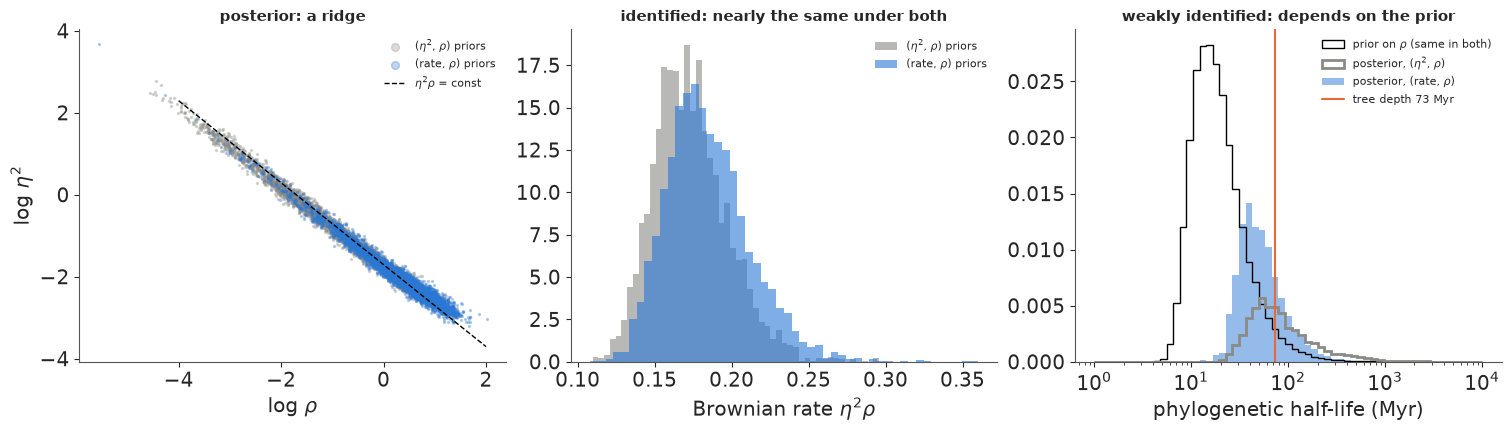

In [13]:
rate_r, rho_r, e2_r = (draws(fits["ou_rate"], "ou_rate::" + v) for v in ["rate", "rho", "eta2"])
with m_ou_rate:
    prior_rho = pm.draw(m_ou_rate["ou_rate::rho"], 20000, random_seed=RANDOM_SEED)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].scatter(np.log(rh), np.log(e2), s=2, alpha=0.3, color=GREY, label="($\\eta^2$, $\\rho$) priors")
axes[0].scatter(np.log(rho_r), np.log(e2_r), s=2, alpha=0.3, color=BLUE, label="(rate, $\\rho$) priors")
xs = np.linspace(-4, 2, 50)
axes[0].plot(xs, np.log(np.median(rate_r)) - xs, color="k", lw=1, ls="--", label="$\\eta^2\\rho$ = const")
axes[0].set(xlabel="log $\\rho$", ylabel="log $\\eta^2$")
axes[0].set_title("posterior: a ridge", fontsize=11)
axes[0].legend(fontsize=8, markerscale=4)
axes[1].hist(e2 * rh, bins=50, density=True, alpha=0.6, color=GREY, label="($\\eta^2$, $\\rho$) priors")
axes[1].hist(rate_r, bins=50, density=True, alpha=0.6, color=BLUE, label="(rate, $\\rho$) priors")
axes[1].set(xlabel="Brownian rate $\\eta^2\\rho$")
axes[1].set_title("identified: nearly the same under both", fontsize=11)
axes[1].legend(fontsize=8)
half_life = lambda r: 2 * T * np.log(2) / r
bins = np.logspace(0, 4, 60)
axes[2].hist(half_life(prior_rho), bins=bins, density=True, histtype="step", color="k", label="prior on $\\rho$ (same in both)")
axes[2].hist(half_life(rh), bins=bins, density=True, histtype="step", lw=2, color=GREY, label="posterior, ($\\eta^2$, $\\rho$)")
axes[2].hist(half_life(rho_r), bins=bins, density=True, alpha=0.5, color=BLUE, label="posterior, (rate, $\\rho$)")
axes[2].axvline(T, color=ORANGE, lw=1.5, label=f"tree depth {T:.0f} Myr")
axes[2].set(xscale="log", xlabel="phylogenetic half-life (Myr)")
axes[2].set_title("weakly identified: depends on the prior", fontsize=11)
axes[2].legend(fontsize=8);

Left: the two posteriors live on the same ridge (dashed line: constant rate); the
reparameterised sampler only moves more easily along it, which is why its effective sample
sizes for $\rho$ and $\eta^2$ are over three times as large (and the reparameterised fit is
faster). Middle: the Brownian rate is nearly the same under both parameterisations - that
is what the data know. Right: the half-life is
where the prior shows. The data rule out very short half-lives (a strong pull to an
optimum, which would make distant relatives uncorrelated sooner than they are) but cannot
tell a half-life comparable to the tree depth from an infinite one, which is Brownian
motion. The prior on $\rho$ is the same HalfNormal(5) in both models, yet the posteriors
of the half-life differ: along a ridge, the prior on the *other* coordinate
(HalfNormal(5) on $\eta^2$ vs HalfNormal(1) on $\eta^2\rho$) decides where the mass sits,
and the vague $\eta^2$ prior lets the chain wander out to half-lives of thousands of Myr,
which is Brownian motion by another name. The honest report is "consistent with Brownian motion; if there is an optimum, the pull is
slow", not a number for $\alpha$.

## 6 · What happened to the slopes

Five models, three coefficients. The two OU fits are the same likelihood with different
priors; they agree on the slopes but not on the intercept, because a small $\rho$ (far out
along the ridge) is a large random intercept - see the expansion above - and the vague
$\eta^2$ prior lets the chain go there.

posterior sd, relative to the i.i.d. model:
coef         a    bG    bM
model                     
iid       1.00  1.00  1.00
lambda    6.86  0.85  1.33
bm        9.93  0.89  1.56
ou       28.44  0.89  1.76
ou_rate  16.75  0.91  1.88


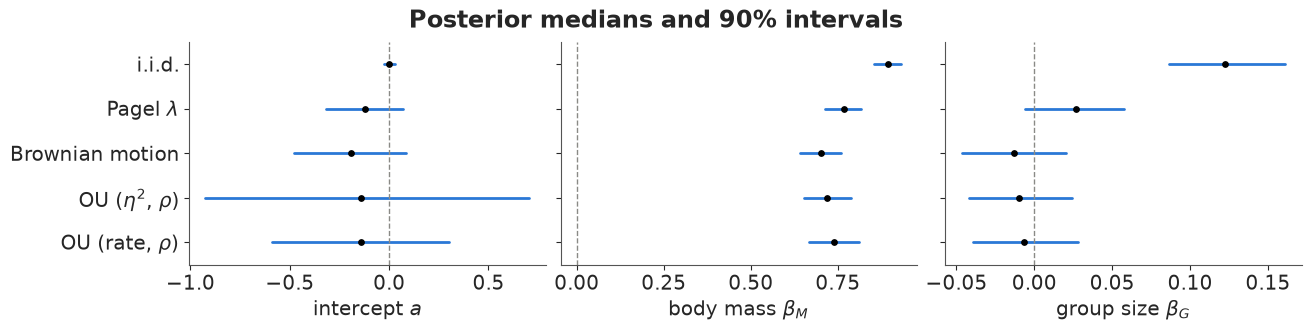

In [14]:
order_models = ["iid", "lambda", "bm", "ou", "ou_rate"]
labels = {"iid": "i.i.d.", "lambda": "Pagel $\\lambda$", "bm": "Brownian motion",
          "ou": "OU ($\\eta^2$, $\\rho$)", "ou_rate": "OU (rate, $\\rho$)"}
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2), sharey=True)
rows = []
for ax, var, xl in zip(axes, ["a", "bM", "bG"], ["intercept $a$", "body mass $\\beta_M$", "group size $\\beta_G$"]):
    for k, mname in enumerate(order_models):
        x = draws(fits[mname], f"{mname}::{var}")
        lo, med, hi = np.quantile(x, [0.05, 0.5, 0.95])
        ax.plot([lo, hi], [k, k], color=BLUE, lw=2)
        ax.scatter(med, k, color="k", zorder=3, s=15)
        rows.append({"model": mname, "coef": var, "median": med, "sd": x.std()})
    ax.axvline(0, color=GREY, ls="--", lw=1)
    ax.set(xlabel=xl)
axes[0].set(yticks=range(len(order_models)), yticklabels=[labels[m] for m in order_models], ylim=(len(order_models) - 0.5, -0.5))
fig.suptitle("Posterior medians and 90% intervals")
sd_tab = pd.DataFrame(rows).pivot(index="model", columns="coef", values="sd").loc[order_models]
print("posterior sd, relative to the i.i.d. model:")
print((sd_tab / sd_tab.loc["iid"]).round(2));

Three lessons in one figure.

- **The group-size effect is a phylogenetic artefact, mostly.** Once shared ancestry is
  modelled, $\beta_G$ is within a few hundredths of zero in every tree model. The i.i.d.
  estimate of 0.12 came from a few deep contrasts (large-bodied, big-group Old World
  monkeys vs small-group strepsirrhines) counted once per species.
- **Uncertainty does not simply grow.** The intercept's sd grows 7-10x under $\lambda$
  and Brownian motion (and 16-29x under OU, whose ridge adds a near-free random intercept):
  the mean brain size of primates is, in effect, estimated from a handful of deep lineages,
  and $a$ is now a statement about the root. $\beta_M$'s sd grows by 30-90%. $\beta_G$'s
  *shrinks* by 10-15%: in a tree model its information comes from differences between close
  relatives (a contrast between two sister species is nearly independent of everything
  else), there are many of those, and the residual noise within them is smaller than the
  i.i.d. $\sigma$. Which coefficients widen depends on where on the tree their predictor
  varies.
- **The body-mass slope drops** from about 0.89 to 0.70-0.77: the famous "brain scales with
  body mass to the 3/4 power" is partly between-clade grade shifts, and within clades the
  scaling is shallower (a known result in comparative neurobiology).

## 7 · Which covariance? Leave-one-out for a correlated likelihood

To compare the models by expected predictive accuracy we want PSIS-LOO. With an i.i.d.
likelihood the log-likelihood splits into one term per species and `az.loo` does the rest.
With `pm.MvNormal` it does not split. Two tempting shortcuts and the right answer:

**Wrong 1: use what PyMC gives you.** `pm.compute_log_likelihood` returns the log density
of the *whole vector* per draw - one "observation". LOO over it leaves out all the data.

In [15]:
m_bm = regression("bm")
ll_joint = fits["bm"].copy()
with m_bm:
    pm.compute_log_likelihood(ll_joint, progressbar=False)
print(dict(ll_joint.log_likelihood["bm::B"].sizes))
print(az.loo(ll_joint))

{'chain': 4, 'draw': 1000}
Computed from 4000 posterior samples and 1.0 observations log-likelihood matrix.

         Estimate       SE
elpd_loo    73.24     0.00
p_loo        3.01        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)        0    0.0%
   (0.70, 1]   (bad)         0    0.0%
    (1, Inf)   (very bad)    1  100.0%



/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1184: UserWarning: The point-wise LOO is the same with the sum LOO, please double check the Observed RV in your model to make sure it returns element-wise logp.
  warnings.warn(


One observation, Pareto $k > 1$: meaningless, and the dimension of the log-likelihood
array tells you so.

**Wrong 2: use the marginal density of each species**, $\text{N}(B_i \mid \mu_i, K_{ii})$.
That has one term per species, and `az.loo` will happily process it. But it scores the
prediction of species $i$ *without* using its relatives, which is not what the model would
do if $i$ were left out and is not the same model at all.

**Right: the conditional (leave-one-out) predictive.** For $y \sim \text{MvNormal}(\mu, K)$,
the distribution of $y_i$ given all the others is normal, and with the precision matrix
$Q = K^{-1}$ it has a closed form (Sundararajan & Keerthi 2001; Bürkner, Gabry & Vehtari 2021):
$$y_i \mid y_{-i} \sim \text{N}\!\left(y_i - \frac{g_i}{Q_{ii}},\ \frac{1}{Q_{ii}}\right),
\qquad g = Q(y - \mu).$$
So one inverse per posterior draw gives all $N$ pointwise log densities
$\log p(y_i \mid y_{-i}, \theta) = -\tfrac12\log 2\pi + \tfrac12 \log Q_{ii} - \tfrac12 g_i^2/Q_{ii}$,
and PSIS then reweights the draws from "fitted with $i$" to "fitted without $i$" as
usual. (That second step is still needed: the formula conditions on $y_{-i}$ at fixed
parameters, PSIS handles the parameters.)

In [16]:
def covariance_draws(mname):
    p = lambda v: draws(fits[mname], f"{mname}::{v}")
    if mname == "iid":
        s = p("sigma")
        return lambda k: s[k] ** 2 * np.eye(N)
    if mname == "bm":
        s = p("sigma")
        return lambda k: s[k] ** 2 * R
    if mname == "lambda":
        s, lam = p("sigma"), p("lam")
        return lambda k: s[k] ** 2 * (lam[k] * R + (1 - lam[k]) * np.eye(N))
    e2, rho = p("eta2"), p("rho")
    return lambda k: e2[k] * np.exp(-rho[k] * Dn) + 1e-6 * np.eye(N)


def pointwise_loglik(mname):
    """(conditional LOO log density, marginal log density), each draws x species."""
    mu = draws(fits[mname], f"{mname}::mu")
    K_of = covariance_draws(mname)
    S = len(mu)
    ll_cond, ll_marg = np.empty((S, N)), np.empty((S, N))
    for k in range(S):
        K = K_of(k)
        Q = np.linalg.inv(K)
        q, g = np.diag(Q), Q @ (B - mu[k])
        ll_cond[k] = -0.5 * np.log(2 * np.pi) + 0.5 * np.log(q) - 0.5 * g**2 / q
        kd = np.diag(K)
        ll_marg[k] = -0.5 * np.log(2 * np.pi * kd) - 0.5 * (B - mu[k]) ** 2 / kd
    return ll_cond, ll_marg


def loo_from(mname, ll):
    n_chain = fits[mname].posterior.sizes["chain"]
    tree = xr.DataTree.from_dict({
        "posterior": fits[mname].posterior.to_dataset(),
        "log_likelihood": xr.Dataset({"B": (("chain", "draw", "species"), ll.reshape(n_chain, -1, N))}),
    })
    res = az.loo(tree, pointwise=True)
    res.log_weights = None       # keep only what az.compare needs
    return res


loo_cond, loo_marg = {}, {}
t0 = time.time()
for mname in ["iid", "lambda", "bm", "ou_rate"]:
    llc, llm = pointwise_loglik(mname)
    loo_cond[mname], loo_marg[mname] = loo_from(mname, llc), loo_from(mname, llm)
print(f"4 models x 4000 draws x one {N}x{N} inverse: {time.time() - t0:.1f} s")
cmp_cond = az.compare(loo_cond)
cmp_marg = az.compare(loo_marg)
print("RIGHT - conditional (leave-one-out) predictive:")
print(cmp_cond[["rank", "elpd", "p", "elpd_diff", "dse", "weight"]].round(1))
print("\nWRONG - marginal pointwise densities:")
print(cmp_marg[["rank", "elpd", "p", "elpd_diff", "dse", "weight"]].round(1))
print("\nPareto k > 0.7 (conditional):", {m: int((loo_cond[m].pareto_k > 0.7).sum()) for m in loo_cond})

/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


4 models x 4000 draws x one 151x151 inverse: 3.6 s
RIGHT - conditional (leave-one-out) predictive:
         rank   elpd     p  elpd_diff   dse  weight
lambda      0  130.0   4.4        0.0   0.0     1.0
bm          1   90.0  12.5      -40.0  21.0     0.0
ou_rate     2   90.0  13.0      -40.0  19.0     0.0
iid         3   20.0   4.1     -110.0  11.0     0.0

WRONG - marginal pointwise densities:
         rank   elpd     p  elpd_diff  dse  weight
iid         0   20.0   4.1        0.0  0.0     1.0
lambda      1  -90.0  45.3     -100.0  8.6     0.0
bm          2 -120.0  36.7     -130.0  9.1     0.0
ou_rate     3 -150.0  79.1     -170.0  8.7     0.0

Pareto k > 0.7 (conditional): {'iid': 0, 'lambda': 0, 'bm': 1, 'ou_rate': 2}


/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn

The two tables rank the models in **opposite** order. The marginal version prefers the
i.i.d. model by a huge margin - of course: scoring each species without its relatives,
the tree models' residual variance $K_{ii}$ is larger (it must also cover the deep
between-clade variation that the relatives would have explained), so each marginal density
is flatter. The conditional version uses the relatives, as a phylogenetic model predicting
a left-out species would, and ranks $\lambda$ first, Brownian motion and OU (which give
near-identical fits, as the ridge analysis predicted) about 40 elpd behind, and the i.i.d.
model last by more than 100. (The $\lambda$-vs-BM difference of about 40 has a standard
error of about 20: clear, not overwhelming.) The i.i.d. model's conditional and marginal elpd are
identical, as they must be.

Why does $\lambda$ beat pure Brownian motion so clearly? Look at where the difference
comes from, species by species.

                            brain    body  group_size
name                                                 
Cercocebus_torquatus       105.99  7485.0       26.85
Cercocebus_torquatus_atys   94.68  8600.0       35.00
species with a relative < 2 Myr away: 14, they account for 34.9 of the total elpd difference 38.6


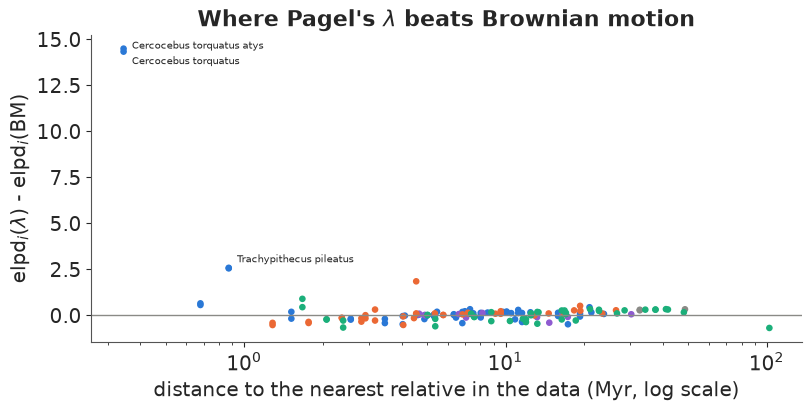

In [17]:
elpd_i = {m: np.asarray(loo_cond[m].elpd_i) for m in loo_cond}
diff = elpd_i["lambda"] - elpd_i["bm"]
nn_dist = D_cc.min(axis=1) * 2 * T
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(nn_dist, diff, s=14, c=[clades[c][1] for c in cc.clade])
ax.axhline(0, color=GREY, lw=1)
ax.set(xscale="log", xlabel="distance to the nearest relative in the data (Myr, log scale)",
       ylabel="elpd$_i$($\\lambda$) - elpd$_i$(BM)",
       title="Where Pagel's $\\lambda$ beats Brownian motion")
for k, i in enumerate(np.argsort(diff)[::-1][:3]):
    ax.annotate(species[i].replace("_", " "), (nn_dist[i], diff[i]), fontsize=7,
                xytext=(6, -9 * k if k < 2 else 4), textcoords="offset points")
print(cc.loc[species[np.argsort(diff)[-2:]], ["brain", "body", "group_size"]])
close = nn_dist < 2
print(f"species with a relative < 2 Myr away: {close.sum()}, they account for "
      f"{diff[close].sum():.1f} of the total elpd difference {diff.sum():.1f}");

The gain is concentrated in species with a very close relative in the data: the 14 species
with a relative less than 2 Myr away carry 35 of the 39 elpd units, and one pair carries
most of it - *Cercocebus torquatus* and its subspecies *C. t. atys*, 0.35 Myr apart in
the tree, where the subspecies is the heavier of the two but has the smaller brain. Pure
Brownian motion predicts each of them almost exactly from the other, with a tiny
predictive variance, and that overconfident prediction is punished hard. The nugget
$1 - \lambda \approx 0.05$ puts a floor under the predictive variance (a different sample
of skulls, a real recent change). This is also why Brownian motion and OU have a large
$p_{\text{loo}}$ and one or two Pareto $k$ values above 0.7: a few species are each
essentially predicted by one sister. An OU model *with* a nugget is the natural next model (Try it
yourself, 2).

The posterior predictive check from section 3, now for all four covariances:

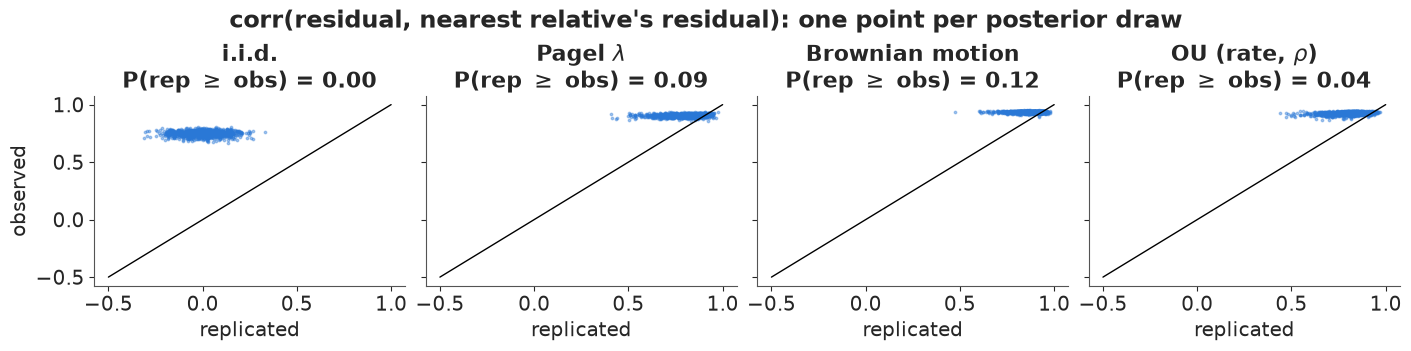

In [18]:
for mname in ["lambda", "bm", "ou_rate"]:
    ppc_stats[mname] = sister_ppc(fits[mname], regression(mname))
fig, axes = plt.subplots(1, 4, figsize=(14, 3.4), sharex=True, sharey=True)
for ax, mname in zip(axes, ["iid", "lambda", "bm", "ou_rate"]):
    obs, rep = ppc_stats[mname]
    ax.scatter(rep, obs, s=3, alpha=0.4, color=BLUE)
    ax.plot([-0.5, 1], [-0.5, 1], color="k", lw=1)
    ax.set(title=f"{labels[mname]}\nP(rep $\\geq$ obs) = {np.mean(rep >= obs):.2f}", xlabel="replicated")
axes[0].set_ylabel("observed");
fig.suptitle("corr(residual, nearest relative's residual): one point per posterior draw");

Each point is one posterior draw: the observed statistic against the one from data
replicated under that draw. For the i.i.d. model all points sit far above the diagonal
(observed 0.75, replicated around 0). For the three tree models the observed residual
correlation is about 0.9 and the replicated values reach it: most of the phylogenetic
signal is reproduced, although the observed value sits in the upper tail of the
replicates (posterior predictive p-values 0.04-0.12, lowest for OU). Close relatives are
even a little more alike than these models expect - a hint that rates of evolution are not
constant across the tree (Try it yourself, 1).

## 8 · Cost: dense covariances, whitening, and the tree's sparse precision

Every gradient of an `MvNormal` with a parameter-dependent covariance costs a Cholesky
factorisation, $O(N^3)$: trivial at $N = 151$, painful at a few thousand species (a
mammal or bird tree). Two remedies.

**Whitening**, when the correlation matrix is fixed (Brownian motion): factor
$R = LL^\top$ once, and $L^{-1}B \sim \text{N}(L^{-1}\mu, \sigma^2 I)$ is an ordinary
independent-normal likelihood with the same posterior.

In [19]:
L = np.linalg.cholesky(R)
Bw = solve_triangular(L, B, lower=True)
Xw = solve_triangular(L, np.column_stack([np.ones(N), M, G]), lower=True)
with pm.Model(name="bm_white") as m_white:
    a = pm.Normal("a", 0, 1)
    bM = pm.Normal("bM", 0, 0.5)
    bG = pm.Normal("bG", 0, 0.5)
    sigma = pm.Exponential("sigma", 1)
    pm.Normal("Bw", Xw[:, 0] * a + Xw[:, 1] * bM + Xw[:, 2] * bG, sigma, observed=Bw)
fit_white = fit(m_white)
for v in ["a", "bM", "bG", "sigma"]:
    print(f"{v:6s} dense: {draws(fits['bm'], 'bm::' + v).mean():+.3f} ± {draws(fits['bm'], 'bm::' + v).std():.3f}"
          f"   whitened: {draws(fit_white, 'bm_white::' + v).mean():+.3f} ± {draws(fit_white, 'bm_white::' + v).std():.3f}")

  bm_white: 0.5 s (incl. compile), divergences = 0
a      dense: -0.193 ± 0.171   whitened: -0.193 ± 0.171
bM     dense: +0.701 ± 0.036   whitened: +0.701 ± 0.036
bG     dense: -0.013 ± 0.020   whitened: -0.013 ± 0.020
sigma  dense: +0.401 ± 0.024   whitened: +0.401 ± 0.024


Identical posteriors (to Monte Carlo error), and the per-gradient cost is now that of an
i.i.d. regression. At this size compile time dominates the wall-clock numbers printed by
`fit`; the saving is in the $O(N^3)$ factorisation, which the whitened model never does.

**The tree's precision is sparse.** The dense $C$ hides a simple structure. Add the
internal nodes as variables: each node is its parent plus an independent increment,
$x_c \sim \text{N}(x_{p(c)}, \sigma^2 \ell_c)$. The joint density of all nodes then has a
precision matrix with a non-zero only for each (parent, child) pair: the weighted
**graph Laplacian of the tree** with weights $1/\ell_c$, with the root held fixed. That is
an intrinsic Gaussian Markov random field on a graph - the ICAR of E18, on a tree instead of
a map. Inverting it and keeping the tip block gives back $C$:

In [20]:
Qt = np.zeros((n_node, n_node))
for p, c in edge:
    w = 1.0 / blen[c]
    Qt[p, p] += w
    Qt[c, c] += w
    Qt[p, c] -= w
    Qt[c, p] -= w
keep = np.setdiff1d(np.arange(n_node), [root])            # condition on the root (= 0)
cov_nodes = np.linalg.inv(Qt[np.ix_(keep, keep)])
tip_block = cov_nodes[:n_tip, :n_tip]                      # tips are nodes 0..300, before the root
print(f"max |inv(Q_tree)[tips] - C| = {np.abs(tip_block - C_full).max():.1e}")
print(f"non-zeros: precision {np.count_nonzero(Qt[np.ix_(keep, keep)]) / keep.size**2:.2%} of {keep.size}^2, "
      f"covariance C {np.count_nonzero(C_full) / n_tip**2:.0%} of {n_tip}^2")

max |inv(Q_tree)[tips] - C| = 5.0e-11
non-zeros: precision 0.50% of 594^2, covariance C 56% of 301^2


Half a percent of the precision is non-zero, against 56% of the covariance (the zeros in
$C$ are only the pairs across the root). Two practical consequences: likelihoods on trees
can be evaluated in $O(N)$ by a recursion (Felsenstein's pruning algorithm; the
`phylolm` trick of Ho & Ané 2014), and in a PPL we can simply **sample the internal nodes**,
non-centred, which costs one parameter per node but no matrix algebra at all. The next
section uses the second option for a trait we have not fully observed.

## 9 · Missing group sizes: impute them on the tree

Sections 3-8 used the 151 species with all three traits and silently dropped 31 species
with a brain and a body mass but no group size. Dropping is not free: it throws away their
brain and body information, and it is only harmless if the missingness is unrelated to the
outcome. The Bayesian alternative treats the missing group sizes as parameters with a
model of their own - and the natural model for a trait of a species is, again, evolution on
the tree.

First, is the missingness innocent?

In [21]:
miss = df.group_size.isna()
print(pd.DataFrame({
    "n": [(~miss).sum(), miss.sum()],
    "median research effort": [df.research_effort[~miss].median(), df.research_effort[miss].median()],
    "median body mass (g)": [df.body[~miss].median(), df.body[miss].median()],
}, index=["group size observed", "group size missing"]))
print(df[miss].clade.value_counts().to_string())

                       n  median research effort  median body mass (g)
group size observed  151                    18.0                4450.0
group size missing    31                     7.5                3532.0
clade
Old World monkeys           12
lemurs, lorises, galagos    10
New World monkeys            5
apes                         4


The species without a group size are spread over all the clades, but they are the
little-studied ones: median research effort (number of publications) 7.5 against 18. So
the data are probably not missing completely at random. An imputation model that uses the tree
assumes they are missing at random *given the phylogeny* (and, through the joint model,
given brain size): a missing species' group size is predicted from its relatives'. That is
a much weaker assumption than complete-case analysis makes, but it is still an assumption.

The model, on all 182 species:

- group size evolves as Brownian motion on the tree: internal nodes are sampled
  non-centred, $x_c = x_{p(c)} + \sigma_G \sqrt{\ell_c}\, z_c$; the observed tip value is
  $G_i \sim \text{N}(x_{p(i)},\ \sqrt{\sigma_G^2 \ell_i + \tau_G^2})$, a terminal branch
  plus a nugget $\tau_G$. Passing a vector with `NaN`s as `observed` makes PyMC create the
  31 missing tips as parameters (automatic imputation).
- brain size: the $\lambda$ regression of section 4, with the completed $G$.

In [22]:
tips_all = df.tip.to_numpy()
N2 = len(df)
B2, M2 = (standardise(df[c].to_numpy()) for c in ["log_brain", "log_body"])
g_raw = df.log_group_size.to_numpy()
G2 = (g_raw - np.nanmean(g_raw)) / np.nanstd(g_raw)
R2 = C_full[np.ix_(tips_all, tips_all)] / T

# internal nodes above the 182 tips, root first; the branch above each non-root node
inner = sorted({int(a) for t in tips_all for a in np.flatnonzero(Anc[t]) if a >= n_tip} | {root},
               key=lambda n: depth[n])
pos = {n: k for k, n in enumerate(inner)}
branch = inner[1:]
A_inner = Anc[np.ix_(inner, branch)]                       # node x branch ancestry, root row = 0
bl_inner = blen[branch] / T
tip_parent = np.array([pos[parent[t]] for t in tips_all])
bl_tip = blen[tips_all] / T
print(f"{len(inner)} internal nodes above the {N2} species; {np.isnan(G2).sum()} group sizes missing")

with pm.Model(coords={"species": df.index.to_numpy(dtype=object)}, name="impute") as m_imp:
    g0 = pm.Normal("g_root", 0, 1)
    sigma_G = pm.Exponential("sigma_G", 1)
    tau_G = pm.Exponential("tau_G", 2)
    z = pm.Normal("z", 0, 1, shape=len(branch))
    x_inner = g0 + pm.math.dot(A_inner, sigma_G * np.sqrt(bl_inner) * z)
    G_full = pm.Normal("G", x_inner[tip_parent], pm.math.sqrt(sigma_G**2 * bl_tip + tau_G**2), observed=G2)
    a = pm.Normal("a", 0, 1)
    bM = pm.Normal("bM", 0, 0.5)
    bG = pm.Normal("bG", 0, 0.5)
    sigma = pm.Exponential("sigma", 1)
    lam = pm.Beta("lam", 1, 1)
    pm.MvNormal("B", a + bM * M2 + bG * G_full, cov=sigma**2 * (lam * R2 + (1 - lam) * np.eye(N2)), observed=B2)
fit_imp = fit(m_imp, target_accept=0.9)
print(summ(fit_imp, ["g_root", "sigma_G", "tau_G", "a", "bM", "bG", "sigma", "lam"]))
s_miss = summ(fit_imp, ["G_unobserved"])
print(f"imputed values: max r_hat {s_miss['r_hat'].max():.3f}, min bulk ESS {s_miss['ess_bulk'].min():.0f}")

264 internal nodes above the 182 species; 31 group sizes missing


  impute: 40.7 s (incl. compile), divergences = 0
          mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  \
g_root  -0.732  0.416    -1.397    -0.092   336.962   532.603  1.008   
sigma_G  1.127  0.114     0.947     1.313   865.682  1105.082  1.002   
tau_G    0.279  0.042     0.214     0.350   846.267  1299.911  1.002   
a       -0.146  0.116    -0.326     0.038  6247.663  3018.238  1.000   
bM       0.735  0.030     0.685     0.783  5107.709  3158.962  1.002   
bG       0.033  0.020     0.002     0.065  4807.765  3584.995  1.000   
sigma    0.277  0.022     0.244     0.315  3942.446  2793.207  1.001   
lam      0.948  0.017     0.917     0.972  3787.562  2791.597  1.000   

         mcse_mean  mcse_sd  
g_root       0.023    0.012  
sigma_G      0.004    0.002  
tau_G        0.001    0.001  
a            0.001    0.002  
bM           0.000    0.000  
bG           0.000    0.000  
sigma        0.000    0.000  
lam          0.000    0.000  
imputed values: max r_hat 1.003

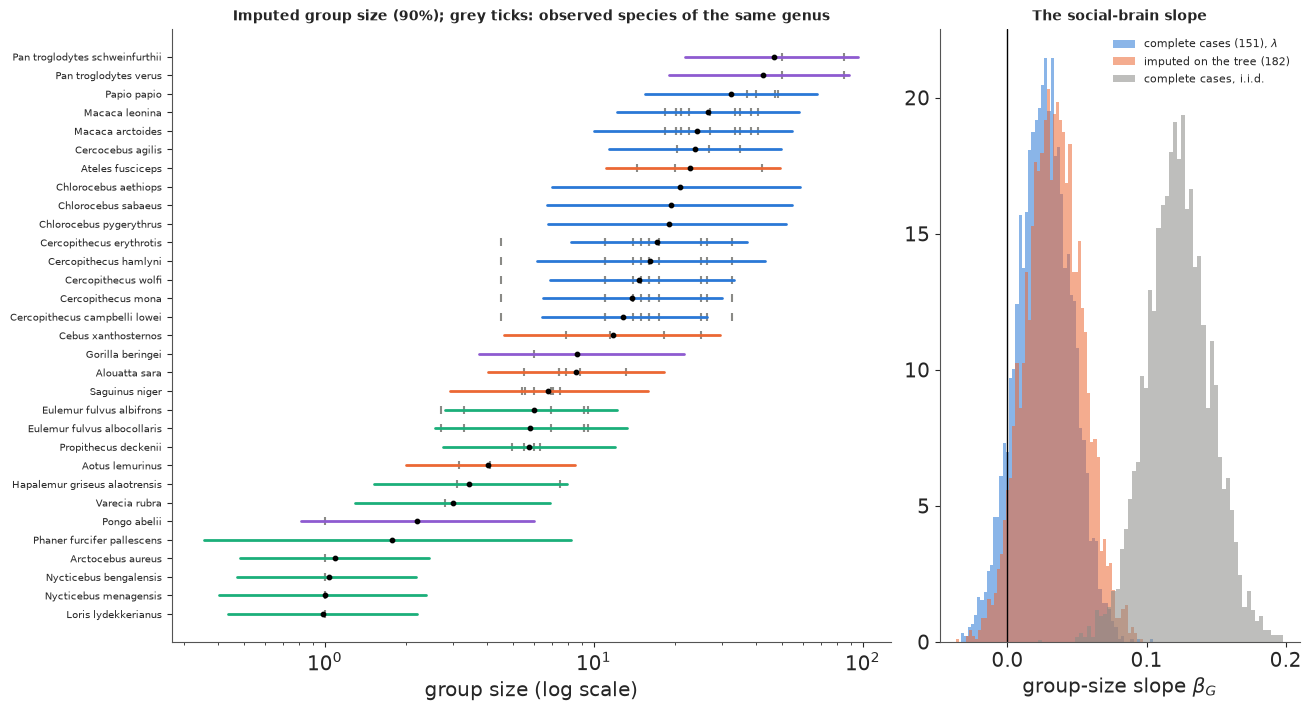

In [23]:
Gm = draws(fit_imp, "impute::G_unobserved")
mu_g, sd_g = np.nanmean(g_raw), np.nanstd(g_raw)
imp_groups = np.exp(Gm * sd_g + mu_g)
mi = np.flatnonzero(np.isnan(G2))
o = np.argsort(np.median(imp_groups, axis=0))
fig, axes = plt.subplots(1, 2, figsize=(13, 7), gridspec_kw={"width_ratios": [2, 1]})
ax = axes[0]
for row, j in enumerate(o):
    sp = df.index[mi[j]]
    lo, med, hi = np.quantile(imp_groups[:, j], [0.05, 0.5, 0.95])
    ax.plot([lo, hi], [row, row], color=clades[df.clade.iloc[mi[j]]][1], lw=2)
    ax.scatter(med, row, color="k", s=10, zorder=3)
    mates = df[(df.genus == df.genus.iloc[mi[j]]) & ~miss].group_size
    ax.scatter(mates, np.full(len(mates), row), marker="|", color=GREY, s=40)
ax.set(xscale="log", yticks=range(len(o)), xlabel="group size (log scale)",
       title="Imputed group size (90%); grey ticks: observed species of the same genus")
ax.title.set_fontsize(10)
ax.set_yticklabels([df.index[mi[j]].replace("_", " ") for j in o], fontsize=7)
ax = axes[1]
for k, (lab, x) in enumerate([("complete cases (151), $\\lambda$", draws(fits["lambda"], "lambda::bG")),
                              ("imputed on the tree (182)", draws(fit_imp, "impute::bG")),
                              ("complete cases, i.i.d.", draws(fits["iid"], "iid::bG"))]):
    ax.hist(x, bins=60, density=True, alpha=0.55, label=lab, color=[BLUE, ORANGE, GREY][k])
ax.axvline(0, color="k", lw=1)
ax.set(xlabel="group-size slope $\\beta_G$")
ax.set_title("The social-brain slope", fontsize=10)
ax.legend(fontsize=8);

The imputations look like what a primatologist would guess from the relatives: the slow
lorises, the slender loris and the golden potto sit at about 1 (their observed relatives
are solitary), the two chimpanzee subspecies at about 45 next to the observed chimpanzees,
the Cercopithecus guenons among their many observed congeners. The three *Chlorocebus*
(vervet) species have no observed genus-mate and borrow from the other guenons. Most
intervals span a factor of 4-8 from end to end - the nugget $\tau_G$ and the terminal
branch set that floor - and the fork-marked lemur *Phaner furcifer pallescens*, with no
observed genus-mate and a long terminal branch, over 20. And the substantive answer is unchanged: with the 31 extra species
the group-size slope moves from 0.027 to 0.034 and its 89% interval still starts at zero,
a far cry from the i.i.d. 0.12.

Two caveats. The imputation model for group size does not use body mass (large-bodied
species tend to live in larger groups): adding $M$ as a predictor of $G$ would sharpen the
imputations. And the brain model feeds back into the imputations (through $\beta_G$) - here
weakly, because $\beta_G$ is near zero.

## 10 · Summary and connections

| Question | Answer here |
|---|---|
| Are species independent data points? | No: close relatives' residuals correlate (section 3's check, $\lambda \approx 0.95$) |
| Where does the covariance come from? | Shared branch length, $C = A\,\text{diag}(\ell)A^\top$; distance $D = 2(T - C)$ on an ultrametric tree |
| Does the social-brain slope survive? | Not in this form: 0.12 (i.i.d.) becomes -0.01 to 0.03, with intervals that include or touch zero |
| Does modelling correlation always widen intervals? | No: the intercept's sd grows ~10x, $\beta_G$'s shrinks slightly - it depends where the predictor varies on the tree |
| Brownian motion or OU? | Indistinguishable: the OU half-life is not identified beyond "not short"; report the Brownian rate $\eta^2\rho$ |
| How to compare correlated-likelihood models? | Conditional LOO from $Q = K^{-1}$ plus PSIS; the marginal shortcut reverses the ranking |
| What about missing traits? | Impute them on the tree inside the model (latent internal nodes = a sparse GMRF) |

**Connections.** The OU model *is* a Gaussian process (E05) whose input space is the tree
and whose distance is patristic; the ridge between $\eta^2$ and $\rho$ is the same
non-identifiability that makes GP length-scales hard, and the fix (put the prior on the
identified combination) carries over. Brownian motion on a tree with its internal nodes is
a Gaussian Markov random field with the weighted tree Laplacian as precision, the same
construction as the ICAR prior on the Scottish district graph in E18; the difference is
that a tree has no cycles, so it can be integrated recursively in $O(N)$. And the lesson
on LOO applies to every model with a non-factorising likelihood: GPs with observed
outcomes, spatial models written as `MvNormal`, and state-space models (E13's one-step-ahead
terms are *not* leave-one-out either).

## Try it yourself

1. **A tree that is not ultrametric.** Multiply the branch lengths of one clade by 2 (as if
   its rate of evolution were faster), rebuild $C$, and fit Pagel's $\lambda$ in its two
   forms: $\sigma^2(\lambda C + (1-\lambda)\,\text{diag}(C))$ and
   $\sigma^2(\lambda R + (1 - \lambda) I)$ with $R$ the correlation matrix of $C$. Which one
   is still "a Brownian part plus a nugget"?
2. **OU with a nugget.** Add a species-level variance to the OU covariance
   ($\eta^2 e^{-\rho D/2T} + \tau^2 I$) with the (rate, $\rho$) parameterisation and redo
   the conditional LOO comparison. Does it catch up with $\lambda$? Is $\rho$ better
   identified once the nugget absorbs the sister-species noise?
3. **Correlated evolution.** Instead of treating body mass and group size as fixed
   predictors, let log brain, log body and log group size co-evolve as a *multivariate*
   Brownian motion: $\text{vec}(Y) \sim \text{MvNormal}(0, \Sigma \otimes R)$ with
   $\Sigma$ from `pm.LKJCholeskyCov`. (Hint: with $R = LL^\top$ fixed, whiten each column
   by $L^{-1}$ first and the Kronecker structure disappears.) Compute the implied
   regression slope of brain on group size given body mass from $\Sigma$ and compare it
   with section 6.